# Results Analysis

Run all three methods under the same setup, compare train/test metrics, and prepare thesis-ready figures.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt

from src.config import default_hyperparams, report_task_suite, one_vs_rest_suite
from src.data import load_mnist_task
from src.experiments import flatten_comparison_rows, format_method_aggregate_summary, format_task_suite_summary, run_task_suite, summarize_method_aggregate
from src.metrics import format_joint_scale_report

baseline_hyper = default_hyperparams()
joint_hyper = default_hyperparams()

FINAL_JOINT_CONFIG = {
    "dictionary_size": 64,
    "mu": 0.15,
    "rho": 10.0,
    "eta": 50.0,
    "gamma": 0.5,
    "max_iter": 100,
}

for key, value in FINAL_JOINT_CONFIG.items():
    setattr(joint_hyper, key, value)

print("baseline hyperparameters:", baseline_hyper)
print("final joint hyperparameters:", joint_hyper)

task_suite = report_task_suite()
# task_suite = one_vs_rest_suite()  # uncomment for the one-vs-rest supplement

task_results = run_task_suite(task_suite, baseline_hyper, joint_hyper)
comparison_rows = flatten_comparison_rows(task_results)

representative_task = task_suite[0]
X_train, y_train, X_val, y_val, X_test, y_test = load_mnist_task(representative_task)
representative_result = task_results[0]
joint_result = representative_result["joint"]["result"]
scale_report = representative_result["joint"]["scale_report"]

print(format_task_suite_summary(task_results))

aggregate_rows = summarize_method_aggregate(comparison_rows)
print("Method-level aggregate summary across tasks:")
print(format_method_aggregate_summary(aggregate_rows))

print("Representative-task comparison rows:")
rep_rows = {row["method"]: row for row in representative_result["comparison_rows"]}
for method in ["Raw SVM", "Separate Dict + SVM", "Joint Dict + SVM"]:
    row = rep_rows[method]
    print({
        "task": representative_task.name,
        "method": method,
        "val_accuracy": row["val_accuracy"],
        "test_accuracy": row["test_accuracy"],
        "val_score_gap": row["val_score_gap"],
        "val_violation_rate": row["val_violation_rate"],
        "val_reconstruction_error": row["val_reconstruction_error"],
        "val_code_sparsity": row["val_code_sparsity"],
    })

for result in task_results:
    task_name = result["task"]["name"]
    print(f"\n=== {task_name} ===")
    print("data shapes:", result["data_shapes"])
    print("joint status:", result["joint"]["result"]["status"])
    print(format_joint_scale_report(result["joint"]["scale_report"]))


baseline hyperparameters: HyperParams(dictionary_size=64, mu=0.05, rho=1.0, gamma=0.1, eta=1.0, initial_step=1.0, backtracking_shrink=0.5, backtracking_min_step=1e-08, max_iter=100, tol=1e-05, random_state=7)
final joint hyperparameters: HyperParams(dictionary_size=64, mu=0.15, rho=10.0, gamma=0.5, eta=50.0, initial_step=1.0, backtracking_shrink=0.5, backtracking_min_step=1e-08, max_iter=100, tol=1e-05, random_state=7)
task | method | train_acc | val_acc | test_acc | train_recon | val_recon | test_recon | train_sparsity | val_sparsity | test_sparsity
3 vs 8 | Raw SVM | 1 | 0.955 | 0.9425 | nan | nan | nan | nan | nan | nan
3 vs 8 | Separate Dict + SVM | 0.974 | 0.975 | 0.945 | 106.54 | 50.9774 | 71.483 | 0.000203125 | 0.00125 | 0.00230469
3 vs 8 | Joint Dict + SVM | 1 | 0.965 | 0.9275 | 124.214 | 55.555 | 77.6696 | 0.000953125 | 0.0172656 | 0.0182422
4 vs 9 | Raw SVM | 1 | 0.94 | 0.925 | nan | nan | nan | nan | nan | nan
4 vs 9 | Separate Dict + SVM | 0.976 | 0.965 | 0.9325 | 83.147 | 

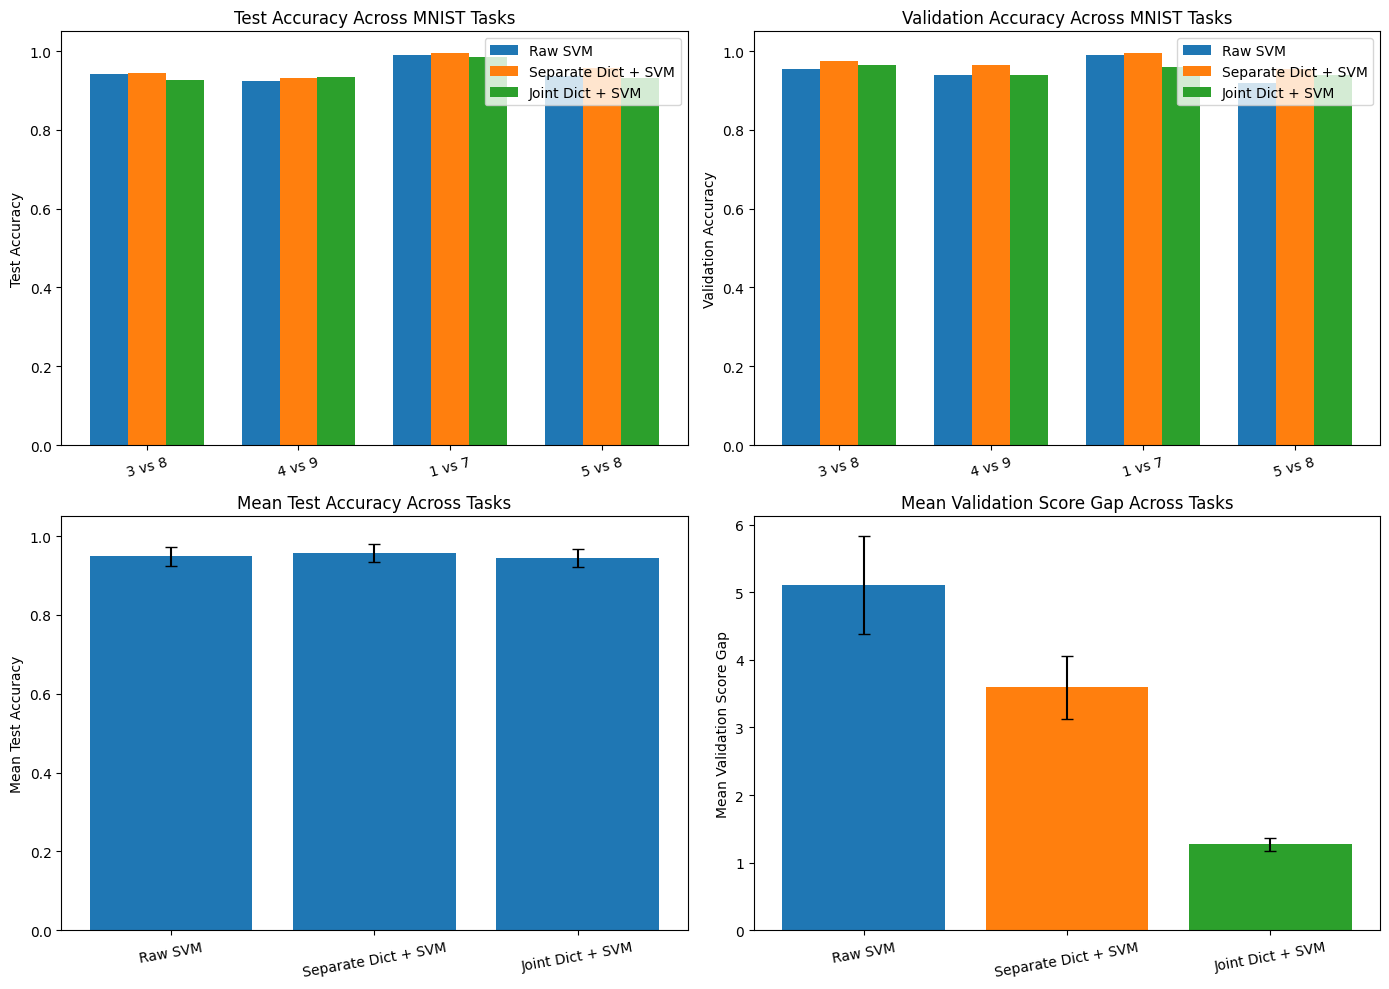

In [3]:
import numpy as np

methods = ["Raw SVM", "Separate Dict + SVM", "Joint Dict + SVM"]
task_names = [result["task"]["name"] for result in task_results]
rows_by_task = {
    result["task"]["name"]: {row["method"]: row for row in result["comparison_rows"]}
    for result in task_results
}
method_rows = {row["method"]: row for row in aggregate_rows}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x = np.arange(len(task_names))
width = 0.25

for offset, method in zip((-width, 0.0, width), methods):
    axes[0, 0].bar(
        x + offset,
        [rows_by_task[task][method]["test_accuracy"] for task in task_names],
        width=width,
        label=method,
    )
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(task_names, rotation=15)
axes[0, 0].set_ylim(0.0, 1.05)
axes[0, 0].set_ylabel("Test Accuracy")
axes[0, 0].set_title("Test Accuracy Across MNIST Tasks")
axes[0, 0].legend()

for offset, method in zip((-width, 0.0, width), methods):
    axes[0, 1].bar(
        x + offset,
        [rows_by_task[task][method]["val_accuracy"] for task in task_names],
        width=width,
        label=method,
    )
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(task_names, rotation=15)
axes[0, 1].set_ylim(0.0, 1.05)
axes[0, 1].set_ylabel("Validation Accuracy")
axes[0, 1].set_title("Validation Accuracy Across MNIST Tasks")
axes[0, 1].legend()

method_x = np.arange(len(methods))
method_test_means = [method_rows[m]["test_accuracy_mean"] for m in methods]
method_test_stds = [method_rows[m]["test_accuracy_std"] for m in methods]
method_gap_means = [method_rows[m]["val_score_gap_mean"] for m in methods]
method_gap_stds = [method_rows[m]["val_score_gap_std"] for m in methods]

axes[1, 0].bar(method_x, method_test_means, yerr=method_test_stds, capsize=4)
axes[1, 0].set_xticks(method_x)
axes[1, 0].set_xticklabels(methods, rotation=10)
axes[1, 0].set_ylim(0.0, 1.05)
axes[1, 0].set_ylabel("Mean Test Accuracy")
axes[1, 0].set_title("Mean Test Accuracy Across Tasks")

axes[1, 1].bar(method_x, method_gap_means, yerr=method_gap_stds, capsize=4, color=["tab:blue", "tab:orange", "tab:green"])
axes[1, 1].set_xticks(method_x)
axes[1, 1].set_xticklabels(methods, rotation=10)
axes[1, 1].set_ylabel("Mean Validation Score Gap")
axes[1, 1].set_title("Mean Validation Score Gap Across Tasks")

plt.tight_layout()
plt.show()


Representative-task baseline comparison (same task, three methods):
task = 3 vs 8
Raw SVM: test_acc=0.9425, val_acc=0.955, val_recon=nan, val_sparsity=nan, val_gap=5.38507, val_violation=0.165
Separate Dict + SVM: test_acc=0.945, val_acc=0.975, val_recon=50.9774, val_sparsity=0.00125, val_gap=3.51043, val_violation=0.27
Joint Dict + SVM: test_acc=0.9275, val_acc=0.965, val_recon=55.555, val_sparsity=0.0172656, val_gap=1.18357, val_violation=0.87


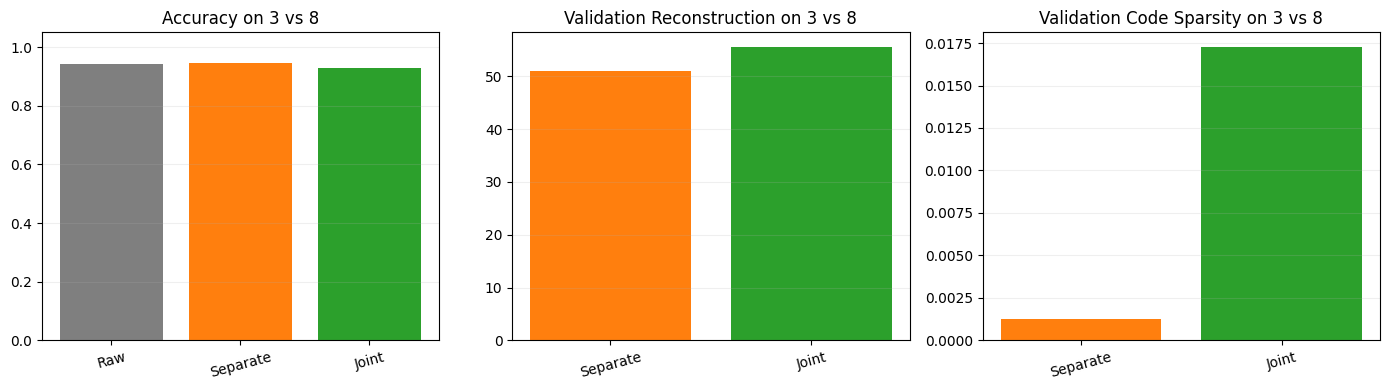

In [4]:
print("Representative-task baseline comparison (same task, three methods):")
print(f"task = {representative_task.name}")
for method in ["Raw SVM", "Separate Dict + SVM", "Joint Dict + SVM"]:
    row = rep_rows[method]
    print(
        f"{method}: test_acc={row['test_accuracy']:.6g}, val_acc={row['val_accuracy']:.6g}, "
        f"val_recon={row['val_reconstruction_error']:.6g}, val_sparsity={row['val_code_sparsity']:.6g}, "
        f"val_gap={row['val_score_gap']:.6g}, val_violation={row['val_violation_rate']:.6g}"
    )

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metric_groups = [
    ("Accuracy", [rep_rows[m]["test_accuracy"] for m in ["Raw SVM", "Separate Dict + SVM", "Joint Dict + SVM"]]),
    ("Validation Reconstruction", [rep_rows[m]["val_reconstruction_error"] for m in ["Raw SVM", "Separate Dict + SVM", "Joint Dict + SVM"]]),
    ("Validation Code Sparsity", [rep_rows[m]["val_code_sparsity"] for m in ["Raw SVM", "Separate Dict + SVM", "Joint Dict + SVM"]]),
]
for ax, (title, values) in zip(axes, metric_groups):
    ax.bar(["Raw", "Separate", "Joint"], values, color=["tab:gray", "tab:orange", "tab:green"])
    ax.set_title(f"{title} on {representative_task.name}")
    ax.tick_params(axis='x', rotation=15)
    if title == "Accuracy":
        ax.set_ylim(0.0, 1.05)
    ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()


Joint-only optimization diagnostics: objective history and step sizes for the tuned joint model.


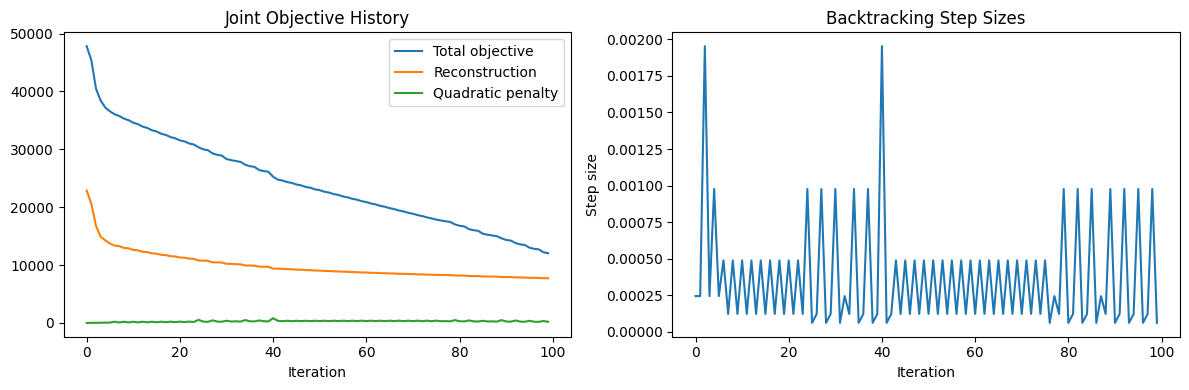

In [5]:
print("Joint-only optimization diagnostics: objective history and step sizes for the tuned joint model.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(joint_result['history']['objective'], label='Total objective')
axes[0].plot(joint_result['history']['reconstruction'], label='Reconstruction')
axes[0].plot(joint_result['history']['quadratic_penalty'], label='Quadratic penalty')
axes[0].set_title('Joint Objective History')
axes[0].set_xlabel('Iteration')
axes[0].legend()

axes[1].plot(joint_result['history']['step_size'])
axes[1].set_title('Backtracking Step Sizes')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Step size')

plt.tight_layout()
plt.show()

Joint-only representation diagnostics: learned dictionary atoms for the tuned joint model.


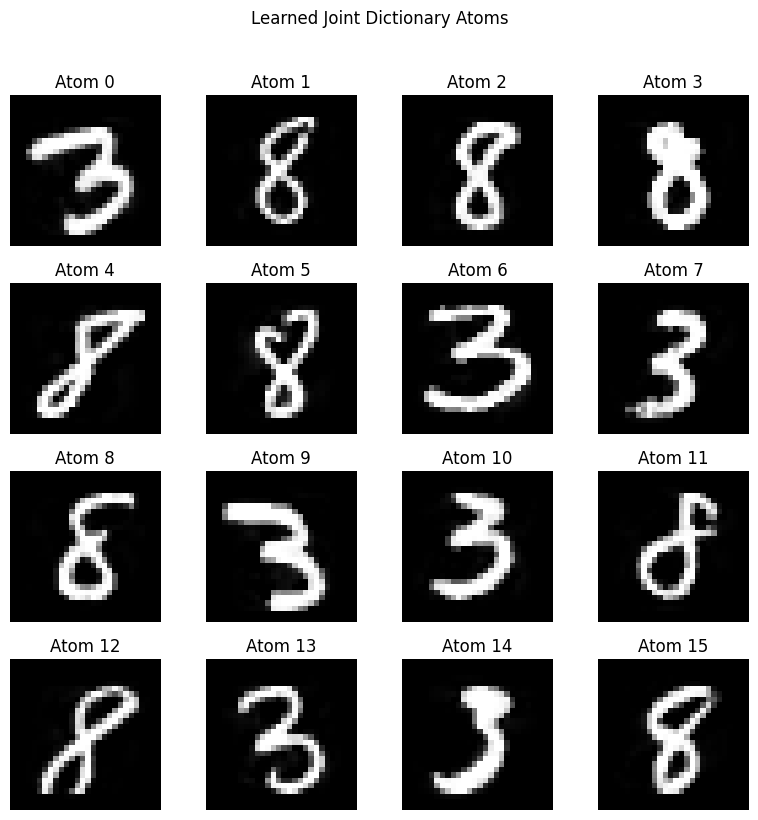

In [6]:
print("Joint-only representation diagnostics: learned dictionary atoms for the tuned joint model.")

import math


D = joint_result['params']['D']
num_atoms = min(16, D.shape[1])
cols = 4
rows = math.ceil(num_atoms / cols)

fig, axes = plt.subplots(rows, cols, figsize=(8, 2 * rows))
axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]

for idx, ax in enumerate(axes):
    ax.axis('off')
    if idx < num_atoms:
        ax.imshow(D[:, idx].reshape(28, 28), cmap='gray')
        ax.set_title(f'Atom {idx}')

plt.suptitle('Learned Joint Dictionary Atoms', y=1.02)
plt.tight_layout()
plt.show()

Joint-only objective scale diagnostic: component fractions for the tuned joint model.
{'component': 'reconstruction', 'initial': 22865.451798872615, 'final': 7714.620807977757, 'max': 22865.451798872615, 'final_fraction_of_total': 0.6408181728934654}
{'component': 'quadratic_penalty', 'initial': 0.1862645149230957, 'final': 185.70762147407447, 'max': 811.3033083482468, 'final_fraction_of_total': 0.015425880499835294}
{'component': 'hinge_term', 'initial': 24847.412109375, 'final': 3685.4805975805716, 'max': 24847.412109375, 'final_fraction_of_total': 0.30613597240367546}
{'component': 'l1_term', 'initial': 112.07131227979475, 'final': 446.42031344880996, 'max': 446.42031344880996, 'final_fraction_of_total': 0.03708208824871374}
{'component': 'classifier_reg', 'initial': 0.0, 'final': 6.475450215001036, 'max': 6.475450215001036, 'final_fraction_of_total': 0.0005378859543100859}


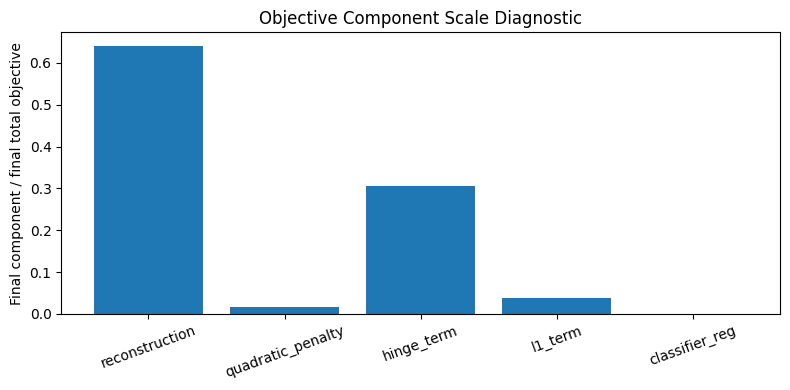

In [7]:
print("Joint-only objective scale diagnostic: component fractions for the tuned joint model.")

scale_rows = [
    {
        'component': name,
        'initial': stats['initial'],
        'final': stats['final'],
        'max': stats['max'],
        'final_fraction_of_total': stats['final_fraction_of_total'],
    }
    for name, stats in scale_report.items()
]

for row in scale_rows:
    print(row)

components = [row['component'] for row in scale_rows]
fractions = [row['final_fraction_of_total'] for row in scale_rows]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(components, fractions)
ax.set_ylabel('Final component / final total objective')
ax.set_title('Objective Component Scale Diagnostic')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [8]:
print("Joint-only hyperparameter sensitivity diagnostic: rho/eta scan on the tuned joint model.")

diagnostic_scan = run_joint_sensitivity_scan(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    base_hyper=joint_hyper,
    rho_values=[1.0, 10.0, 50.0, 100.0],
    eta_values=[1.0, 10.0, 50.0, 100.0],
    seeds=[joint_hyper.random_state],
)

print(summarize_sensitivity_scan(diagnostic_scan, top_k=8))

for row in diagnostic_scan[:8]:
    print(row)

Joint-only hyperparameter sensitivity diagnostic: rho/eta scan on the tuned joint model.


NameError: name 'run_joint_sensitivity_scan' is not defined

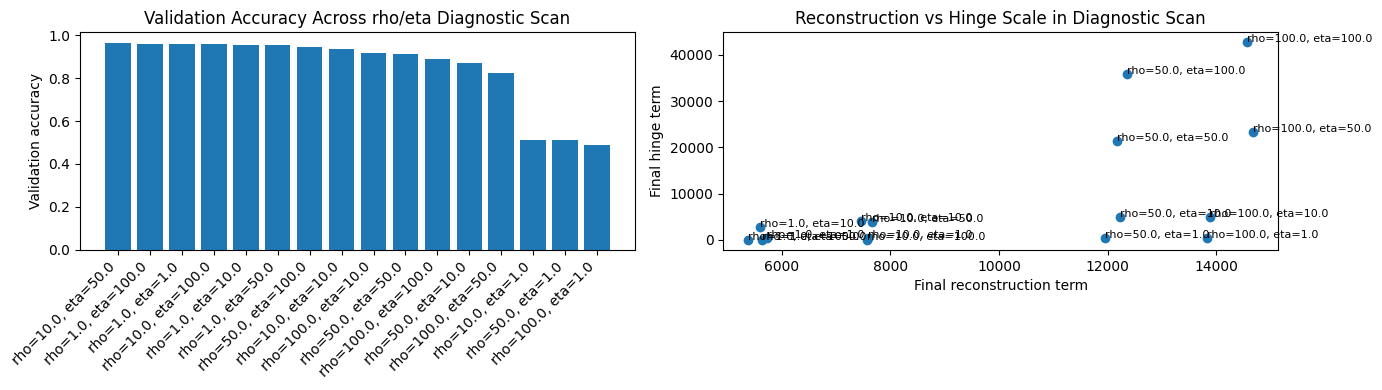

In [ ]:
print("Joint-only rho/eta diagnostic summary.")

rho_eta_labels = [f"rho={row['rho']}, eta={row['eta']}" for row in diagnostic_scan]
val_acc = [row['val_accuracy'] for row in diagnostic_scan]
recon_final = [row['final_reconstruction'] for row in diagnostic_scan]
hinge_final = [row['final_hinge_term'] for row in diagnostic_scan]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(len(val_acc)), val_acc)
axes[0].set_title('Validation Accuracy Across rho/eta Diagnostic Scan')
axes[0].set_ylabel('Validation accuracy')
axes[0].set_xticks(range(len(val_acc)))
axes[0].set_xticklabels(rho_eta_labels, rotation=45, ha='right')

axes[1].scatter(recon_final, hinge_final)
for idx, label in enumerate(rho_eta_labels):
    axes[1].annotate(label, (recon_final[idx], hinge_final[idx]), fontsize=8)
axes[1].set_title('Reconstruction vs Hinge Scale in Diagnostic Scan')
axes[1].set_xlabel('Final reconstruction term')
axes[1].set_ylabel('Final hinge term')

plt.tight_layout()
plt.show()

## Interpretation Notes

- Compare `test_accuracy` across all three methods, not baseline test accuracy against joint train accuracy.
- The joint method evaluates the test split by fixing the learned dictionary and classifier, then inferring sparse codes for the test images.
- Before changing the formula, inspect whether the reconstruction term dominates the classification-related terms by a large margin.
- If the reconstruction term is consistently much larger than the quadratic penalty and hinge term, objective normalization becomes a justified next step rather than an arbitrary rewrite.
- The `rho/eta` diagnostic scan is not the final tuning stage. It is a sensitivity check used to decide whether the current objective scaling is already workable.
- If the joint method is still weaker after diagnostics, the next suspects are hyperparameters (`mu`, `rho`, `eta`, `gamma`), dictionary size, and optimization budget (`max_iter`).